# PS2 Computational Verification Notebook

## Strategic Disclosure, AI Evaluation, and Capital Allocation

**Final runnable version — canonical Python files unchanged**

This notebook is the computational artifact for the PS2 project. It runs the **existing five canonical Python files exactly as supplied**; the notebook does not rewrite or patch them.

### Research question

> When firms know how an AI evaluator scores their disclosures, can a history-aware evaluator and an auction-based allocation mechanism reduce strategic disclosure while preserving informative pricing?

### Experimental design

- **Evaluator designs:** `no_memory`, `naive_history`, `capital_purged`
- **Allocation mechanisms:** `uniform_price`, `bookbuilding`
- **Issuers:** 200, organized as 10 cohorts × 20 issuers
- **Burn-in:** first 2 cohorts excluded from headline summaries
- **Investors:** 15 institutional + 35 retail
- **Seeds:** 42, 43, 44, 45, 46
- **Shares per issuance:** 100

The notebook is intentionally independent of GitHub: upload the five Python files in the first execution cell. The same files can later be placed in the team's GitHub repository.

## 1. Environment

Install only the packages required by the existing implementation. **Do not edit the five Python files in this notebook.**

In [1]:
!pip -q install numpy pandas matplotlib

## 2. Upload the five canonical Python files

Upload exactly:

1. `model.py`
2. `evaluator.py`
3. `auction.py`
4. `simulation.py`
5. `run_experiment.py`

The cell verifies that all five files are present before importing them.

In [2]:
from google.colab import files
from pathlib import Path
import hashlib

required_files = ['model.py', 'evaluator.py', 'auction.py', 'simulation.py', 'run_experiment.py']

uploaded = files.upload()
missing = [f for f in required_files if not Path(f).exists()]
if missing:
    raise FileNotFoundError('Missing required files: ' + ', '.join(missing))

print('All five canonical PS2 Python files are present.')
print('SHA-256 hashes for this run:')
file_hashes = {}
for f in required_files:
    digest = hashlib.sha256(Path(f).read_bytes()).hexdigest()
    file_hashes[f] = digest
    print(f'✓ {f}: {digest}')

All five canonical PS2 Python files are present.
✓ model.py: 06187927125a4b43acc2f6b582505c577f98e295b7bfb47b63ab91412d67915d
✓ evaluator.py: e95ebda8b81818501a74c654cf50c8bd742235f17c3e5ffb0ec3dff641886fd7
✓ auction.py: 9a10bb9e2532788b22a8aad816ab01e203762bb80b6d6a230d6ed0e0e7333cb5
✓ simulation.py: 5513c81bc18dcbe549d50e6e8fb300ad4da859cc0ffe34ca0a9c6af07584312b
✓ run_experiment.py: 12cddfae0eb41612398d89d738ce7a4799512941d4520bebee785adbcef1f4bf


## 3. Verify the model configuration

The values below are read directly from `model.py`. In particular, the canonical implementation contains explicit values for `v_mean`, `v_sd`, `rho_mean`, `rho_sd`, `psi_sd_uniform`, and `psi_sd_bookbuilding`; these are implementation values that should be documented in the final paper if exact numerical parity is claimed.

In [3]:
from model import Config
cfg = Config()
cfg.validate()

model_fields = [
    'n_issuers','n_cohorts','issuers_per_cohort','burn_in_cohorts',
    'shares','n_institutional','n_retail','n_investors',
    'gamma','sigma_theta','sigma_eta','mu0','beta','b_true',
    'sigma_epsilon','sigma_xi_institutional','sigma_xi_retail',
    'lambda_P','kappa0','bookbuilding_institutional_share',
    'bookbuilding_discount','v_mean','v_sd','rho_mean','rho_sd',
    'psi_sd_uniform','psi_sd_bookbuilding'
]

print('PS2 configuration')
print('=' * 60)
for name in model_fields:
    print(f'{name}: {getattr(cfg, name)}')
print('\nConfiguration validation passed.')

PS2 configuration
n_issuers: 200
n_cohorts: 10
issuers_per_cohort: 20
burn_in_cohorts: 2
shares: 100.0
n_institutional: 15
n_retail: 35
n_investors: 50
gamma: 0.006
sigma_theta: 1.0
sigma_eta: 0.5
mu0: 8.5
beta: 0.6
b_true: 1.02
sigma_epsilon: 0.8
sigma_xi_institutional: 1.0
sigma_xi_retail: 2.5
lambda_P: 1.0
kappa0: 0.0
bookbuilding_institutional_share: 0.85
bookbuilding_discount: 0.08
v_mean: 2.2
v_sd: 0.4
rho_mean: 0.5
rho_sd: 0.12
psi_sd_uniform: 0.08
psi_sd_bookbuilding: 0.2

Configuration validation passed.


## 4. Verify the evaluator treatments

In [4]:
from evaluator import MODES
expected_modes = ('no_memory', 'naive_history', 'capital_purged')
print('Evaluator modes:', MODES)
assert MODES == expected_modes
print('Evaluator configuration verified.')

Evaluator modes: ('no_memory', 'naive_history', 'capital_purged')
Evaluator configuration verified.


## 5. Verify the allocation mechanisms

The canonical auction implementation compares:

- **Uniform-price:** bids are ranked and accepted until the issue is allocated; accepted investors pay the lowest accepted bid.
- **Bookbuilding:** the canonical implementation uses underwriter discretion, an 85% institutional allocation share, and an 8% pricing discount.

These rules are read from the existing Python implementation rather than reimplemented here.

In [5]:
from simulation import MECHANISMS
print('Allocation mechanisms:', MECHANISMS)
assert MECHANISMS == ('uniform_price', 'bookbuilding')
print('Auction configuration verified.')
print('Bookbuilding institutional share:', cfg.bookbuilding_institutional_share)
print('Bookbuilding discount:', cfg.bookbuilding_discount)

Allocation mechanisms: ('uniform_price', 'bookbuilding')
Auction configuration verified.
Bookbuilding institutional share: 0.85
Bookbuilding discount: 0.08


## 6. Inspect one complete simulation

This single run is a sanity check only. The final reported results come from the full 3 × 2 × 5-seed experiment below.

In [6]:
from simulation import run
example = run(seed=42, mode='no_memory', mechanism='uniform_price', cfg=cfg)
print('Example simulation completed.')
print('Number of observations:', len(example))
display(example.head(10))

Example simulation completed.
Number of observations: 200


,seed,cohort,firm_id,memory,mechanism,theta,v,rho,m,disclosure,ai_signal,price,capital,psi,performance,epsilon,manipulation_cost,price_error,retail_share,feedback_bias,first_stage_F
0,42,0,0,no_memory,uniform_price,8.804717,1.784006,0.590054,0.327544,9.132261,9.276756,8.790736,8.459942,-0.037630,13.285439,-0.511102,8.940399,-0.013981,0.7,0.0,NaN
1,42,0,1,no_memory,uniform_price,8.224858,2.797977,0.396100,0.513708,8.738566,9.044296,8.275595,8.563204,0.034754,11.806934,0.190188,21.991368,0.050737,0.7,0.0,NaN
2,42,0,2,no_memory,uniform_price,7.905850,1.621577,0.508656,0.297722,8.203572,8.258561,7.446282,8.001222,0.074526,12.283677,0.307961,7.386508,-0.459568,0.7,0.0,NaN
3,42,0,3,no_memory,uniform_price,8.343362,2.183695,0.421425,0.400926,8.744289,8.888003,8.266203,8.382971,0.014126,11.008649,-0.867510,13.395165,-0.077159,0.7,0.0,NaN
4,42,0,4,no_memory,uniform_price,8.590490,2.291291,0.802097,0.420681,9.011171,9.489151,8.911770,9.760985,0.095291,16.629945,0.210199,14.747715,0.321280,0.7,0.0,0.237555
5,42,0,5,no_memory,uniform_price,8.980143,1.502166,0.611293,0.275798,9.255941,9.203689,8.648580,8.671261,0.002623,13.307573,-0.973248,6.338693,-0.331564,0.7,0.0,0.205600
6,42,0,6,no_memory,uniform_price,7.828860,2.324804,0.638637,0.426834,8.255694,8.638766,7.614106,6.206957,-0.184808,11.836337,0.043483,15.182270,-0.214753,0.7,0.0,2.752015
7,42,0,7,no_memory,uniform_price,8.028224,2.383754,0.584234,0.437657,8.465881,8.623421,7.684908,8.341029,0.085378,12.636150,-0.265191,15.961992,-0.343316,0.7,0.0,1.956092
8,42,0,8,no_memory,uniform_price,9.614592,2.353351,0.484263,0.432075,10.046668,9.655286,9.339506,8.801939,-0.057558,12.675047,-1.202003,15.557416,-0.275086,0.7,0.0,1.123806
9,42,0,9,no_memory,uniform_price,5.535471,1.982602,0.790450,0.364006,5.899477,7.143554,5.397233,4.859897,-0.099558,8.665938,-0.711038,11.041679,-0.138238,0.7,0.0,1.002568


In [7]:
print('Columns generated by the simulation:')
for column in example.columns:
    print('-', column)

Columns generated by the simulation:
- seed
- cohort
- firm_id
- memory
- mechanism
- theta
- v
- rho
- m
- disclosure
- ai_signal
- price
- capital
- psi
- performance
- epsilon
- manipulation_cost
- price_error
- retail_share
- feedback_bias
- first_stage_F


## 7. Inspect strategic variables

The simulation records latent quality, firm type, manipulation, disclosure, AI score, price, capital, and realized performance.

In [8]:
cols = ['theta','v','rho','m','disclosure','ai_signal','price','capital','performance']
display(example[cols].head(10))

,theta,v,rho,m,disclosure,ai_signal,price,capital,performance
0,8.804717,1.784006,0.590054,0.327544,9.132261,9.276756,8.790736,8.459942,13.285439
1,8.224858,2.797977,0.396100,0.513708,8.738566,9.044296,8.275595,8.563204,11.806934
2,7.905850,1.621577,0.508656,0.297722,8.203572,8.258561,7.446282,8.001222,12.283677
3,8.343362,2.183695,0.421425,0.400926,8.744289,8.888003,8.266203,8.382971,11.008649
4,8.590490,2.291291,0.802097,0.420681,9.011171,9.489151,8.911770,9.760985,16.629945
5,8.980143,1.502166,0.611293,0.275798,9.255941,9.203689,8.648580,8.671261,13.307573
6,7.828860,2.324804,0.638637,0.426834,8.255694,8.638766,7.614106,6.206957,11.836337
7,8.028224,2.383754,0.584234,0.437657,8.465881,8.623421,7.684908,8.341029,12.636150
8,9.614592,2.353351,0.484263,0.432075,10.046668,9.655286,9.339506,8.801939,12.675047
9,5.535471,1.982602,0.790450,0.364006,5.899477,7.143554,5.397233,4.859897,8.665938


## 8. Run the full PS2 experiment

This is the canonical experiment already implemented in `run_experiment.py`: **3 evaluator modes × 2 allocation mechanisms × 5 seeds**. Each treatment contains 10 cohorts × 20 issuers. Headline summaries exclude the first two cohorts as burn-in.

In [9]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, 'run_experiment.py'],
    capture_output=True,
    text=True
)

print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError('run_experiment.py failed.')

print('Full PS2 experiment completed successfully.')

seed=42 mode=no_memory mechanism=uniform_price
seed=42 mode=no_memory mechanism=bookbuilding
seed=42 mode=naive_history mechanism=uniform_price
seed=42 mode=naive_history mechanism=bookbuilding
seed=42 mode=capital_purged mechanism=uniform_price
seed=42 mode=capital_purged mechanism=bookbuilding
seed=43 mode=no_memory mechanism=uniform_price
seed=43 mode=no_memory mechanism=bookbuilding
seed=43 mode=naive_history mechanism=uniform_price
seed=43 mode=naive_history mechanism=bookbuilding
seed=43 mode=capital_purged mechanism=uniform_price
seed=43 mode=capital_purged mechanism=bookbuilding
seed=44 mode=no_memory mechanism=uniform_price
seed=44 mode=no_memory mechanism=bookbuilding
seed=44 mode=naive_history mechanism=uniform_price
seed=44 mode=naive_history mechanism=bookbuilding
seed=44 mode=capital_purged mechanism=uniform_price
seed=44 mode=capital_purged mechanism=bookbuilding
seed=45 mode=no_memory mechanism=uniform_price
seed=45 mode=no_memory mechanism=bookbuilding
seed=45 mode=nai

## 9. Load and inspect the generated results

The canonical script writes:

- `results/main_results.csv`
- `results/summary_results.csv`
- five PNG figures
- `results/fresh_run_record.json`

No numerical result is typed manually into this notebook.

In [10]:
from pathlib import Path
import pandas as pd

results_dir = Path('results')
main_results = pd.read_csv(results_dir / 'main_results.csv')
summary = pd.read_csv(results_dir / 'summary_results.csv')

print('Main results shape:', main_results.shape)
print('Summary shape:', summary.shape)
display(summary)

Main results shape: (6000, 21)
Summary shape: (6, 11)


,memory,mechanism,mean_manipulation,mean_manipulation_cost,price_rmse,capital_rho_corr,feedback_bias,footprint_cov_k_d_over_var_d,retail_allocation_share,mean_first_stage_F,mean_capital
0,capital_purged,bookbuilding,1.002346,107.818606,14.320513,0.014451,2.526922,5.399278,0.15,0.899504,18.491474
1,capital_purged,uniform_price,1.276756,198.526846,26.478291,0.015275,4.893915,10.487949,0.70,0.136189,26.315612
2,naive_history,bookbuilding,0.920814,91.927863,12.302000,-0.006997,2.012377,4.438084,0.15,0.866363,16.642243
3,naive_history,uniform_price,1.366761,243.229848,30.327759,-0.011869,5.343903,11.777588,0.70,0.139973,28.322286
4,no_memory,bookbuilding,0.407777,14.304540,0.776329,0.036946,0.402932,0.824780,0.15,2.286989,7.767813
5,no_memory,uniform_price,0.407777,14.304540,0.550512,0.055276,0.460594,0.946223,0.70,0.310002,8.096784


## 10. Strategic disclosure

The primary disclosure outcome is mean manipulation $E[m]$. Lower values indicate less strategic disclosure in this simulated environment.

In [11]:
display(summary[['memory','mechanism','mean_manipulation','mean_manipulation_cost']].sort_values(['memory','mechanism']).reset_index(drop=True))

,memory,mechanism,mean_manipulation,mean_manipulation_cost
0,capital_purged,bookbuilding,1.002346,107.818606
1,capital_purged,uniform_price,1.276756,198.526846
2,naive_history,bookbuilding,0.920814,91.927863
3,naive_history,uniform_price,1.366761,243.229848
4,no_memory,bookbuilding,0.407777,14.304540
5,no_memory,uniform_price,0.407777,14.304540


## 11. Pricing informativeness

The canonical price metric is `price_rmse`, computed as $\sqrt{E[(P-	heta)^2]}$. Lower RMSE means simulated price is closer to latent issuer quality.

In [12]:
display(summary[['memory','mechanism','price_rmse']].sort_values(['memory','mechanism']).reset_index(drop=True))

,memory,mechanism,price_rmse
0,capital_purged,bookbuilding,14.320513
1,capital_purged,uniform_price,26.478291
2,naive_history,bookbuilding,12.302000
3,naive_history,uniform_price,30.327759
4,no_memory,bookbuilding,0.776329
5,no_memory,uniform_price,0.550512


## 12. Capital allocation

The canonical allocation metric is `capital_rho_corr = Corr(k, rho)`, reported descriptively as the relationship between capital received and the simulated capital-productivity parameter $
ho$.

In [13]:
display(summary[['memory','mechanism','capital_rho_corr','mean_capital']].sort_values(['memory','mechanism']).reset_index(drop=True))

,memory,mechanism,capital_rho_corr,mean_capital
0,capital_purged,bookbuilding,0.014451,18.491474
1,capital_purged,uniform_price,0.015275,26.315612
2,naive_history,bookbuilding,-0.006997,16.642243
3,naive_history,uniform_price,-0.011869,28.322286
4,no_memory,bookbuilding,0.036946,7.767813
5,no_memory,uniform_price,0.055276,8.096784


## 13. Feedback bias and the capital footprint

The canonical script defines:

`feedback_bias = regression_slope(performance on disclosure) - b_true`.

Therefore, **feedback bias is not the evaluator's stored internal $b$ parameter**. The implied regression slope is `b_true + feedback_bias`. The notebook reports both the canonical bias and the implied slope so the paper does not confuse the two quantities.

`footprint_cov_k_d_over_var_d` is the disclosure-capital covariance footprint reported by the script. `mean_first_stage_F` is the first-stage diagnostic generated by the canonical simulation.

In [14]:
feedback_view = summary[['memory','mechanism','feedback_bias','footprint_cov_k_d_over_var_d','mean_first_stage_F']].copy()
feedback_view['implied_regression_slope'] = cfg.b_true + feedback_view['feedback_bias']
display(feedback_view.sort_values(['memory','mechanism']).reset_index(drop=True))

,memory,mechanism,feedback_bias,footprint_cov_k_d_over_var_d,mean_first_stage_F,implied_regression_slope
0,capital_purged,bookbuilding,2.526922,5.399278,0.899504,3.546922
1,capital_purged,uniform_price,4.893915,10.487949,0.136189,5.913915
2,naive_history,bookbuilding,2.012377,4.438084,0.866363,3.032377
3,naive_history,uniform_price,5.343903,11.777588,0.139973,6.363903
4,no_memory,bookbuilding,0.402932,0.824780,2.286989,1.422932
5,no_memory,uniform_price,0.460594,0.946223,0.310002,1.480594


## 14. Retail access

The canonical script reports `retail_allocation_share`, the mean share of issued capital allocated to retail investors.

In [15]:
display(summary[['memory','mechanism','retail_allocation_share']].sort_values(['memory','mechanism']).reset_index(drop=True))

,memory,mechanism,retail_allocation_share
0,capital_purged,bookbuilding,0.15
1,capital_purged,uniform_price,0.70
2,naive_history,bookbuilding,0.15
3,naive_history,uniform_price,0.70
4,no_memory,bookbuilding,0.15
5,no_memory,uniform_price,0.70


## 15. Visual results

The five figures below are generated directly by `run_experiment.py`. They are not separately recreated in the notebook.


manipulation.png


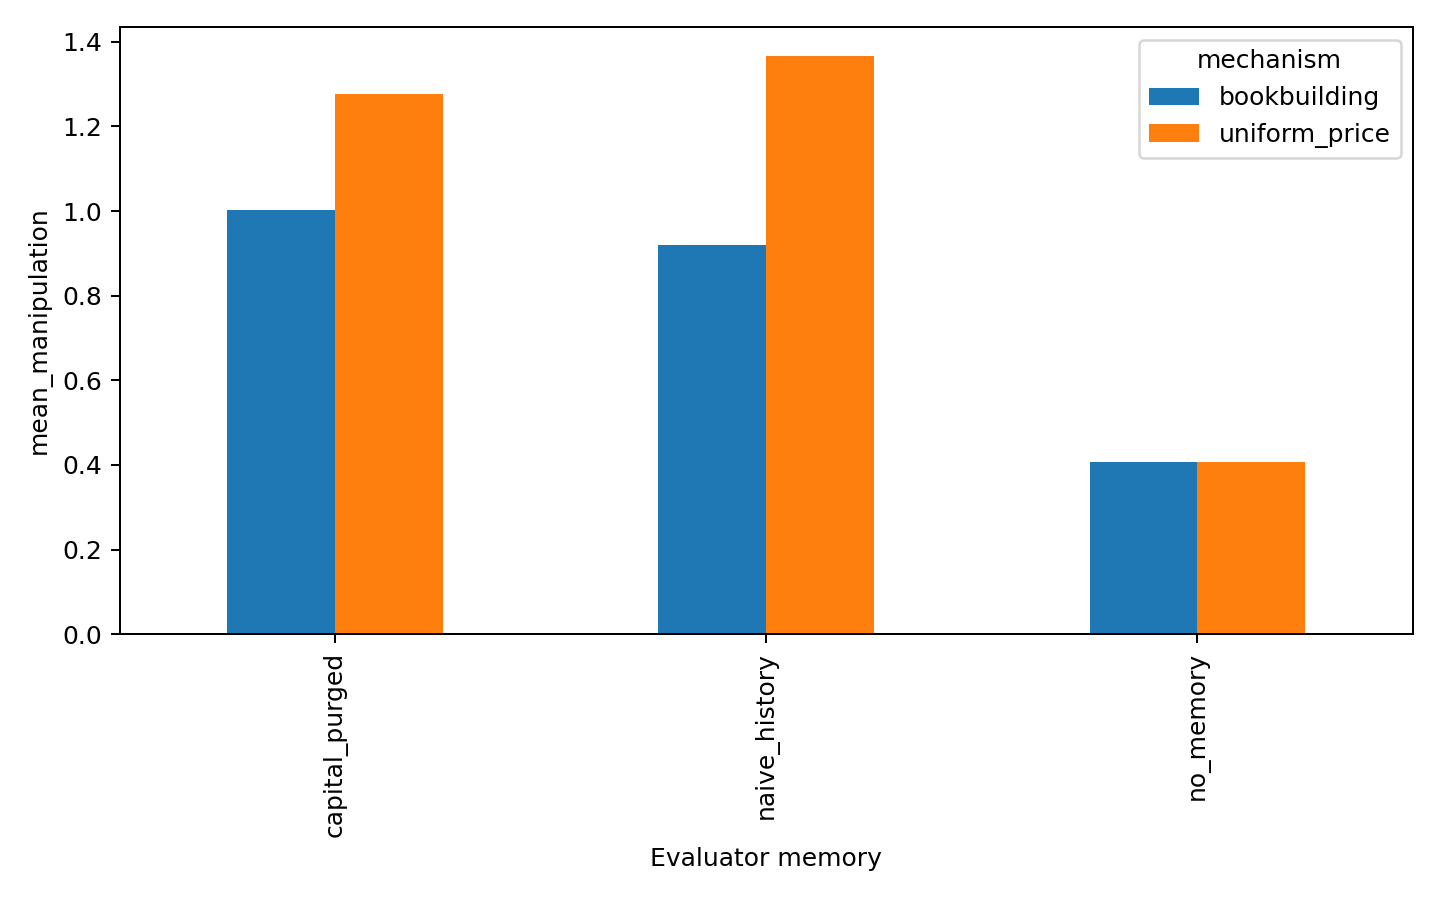


price_rmse.png


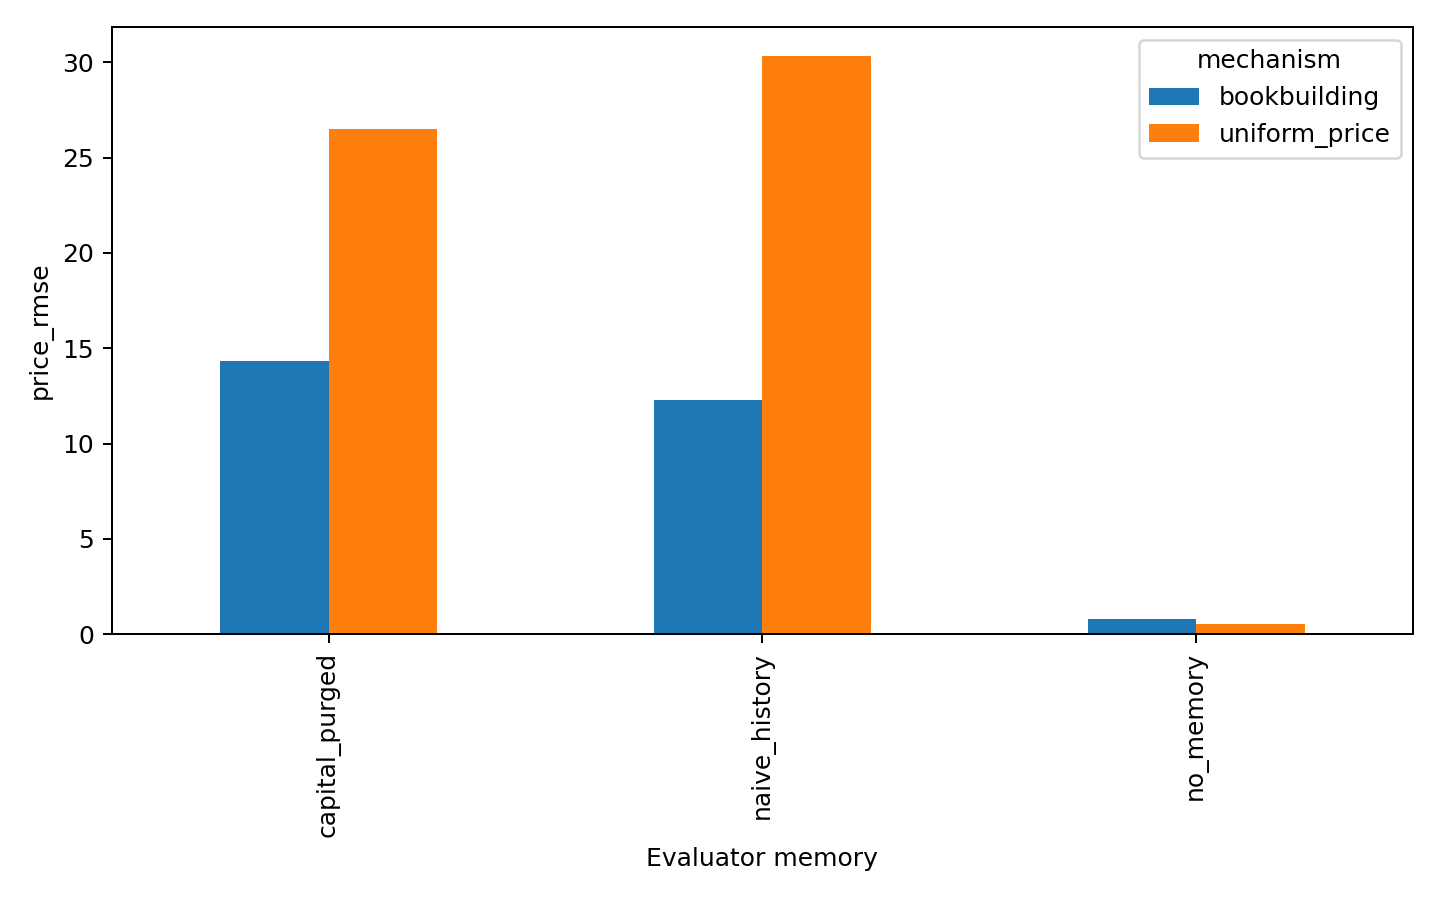


allocation_efficiency.png


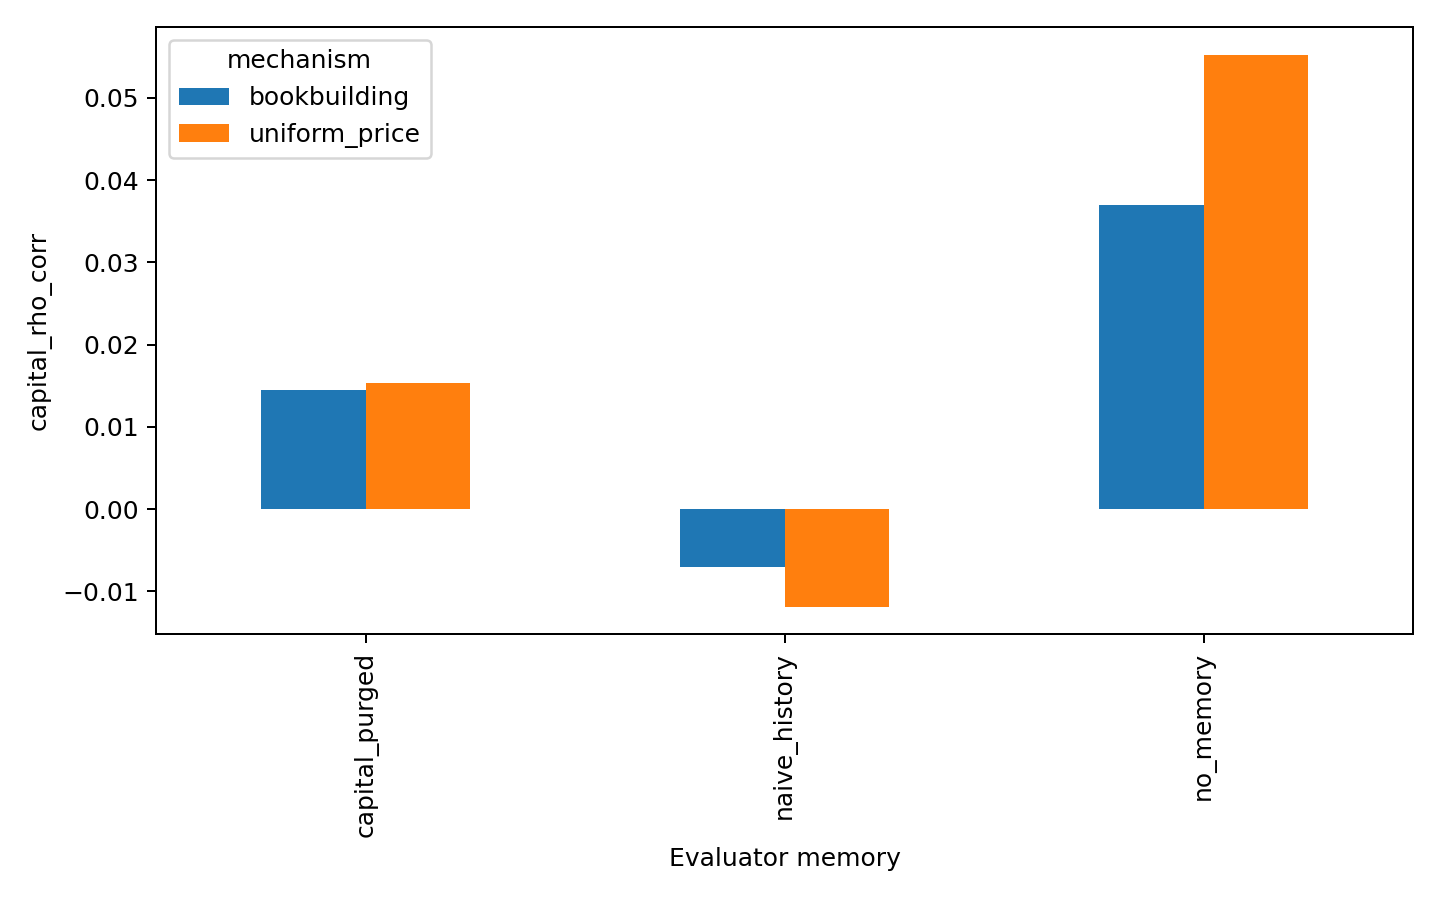


feedback_bias.png


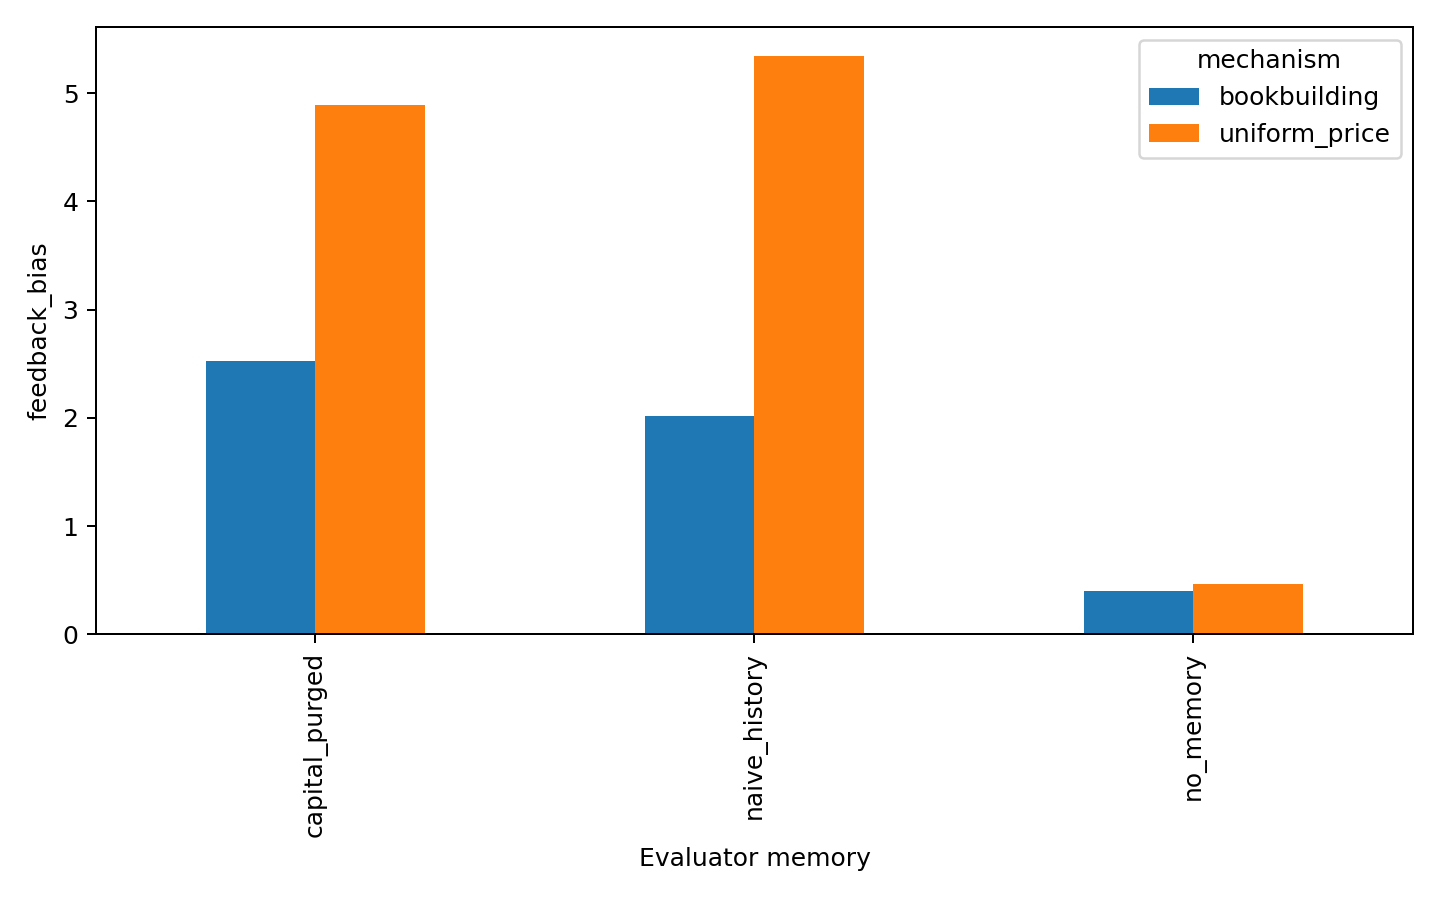


retail_access.png


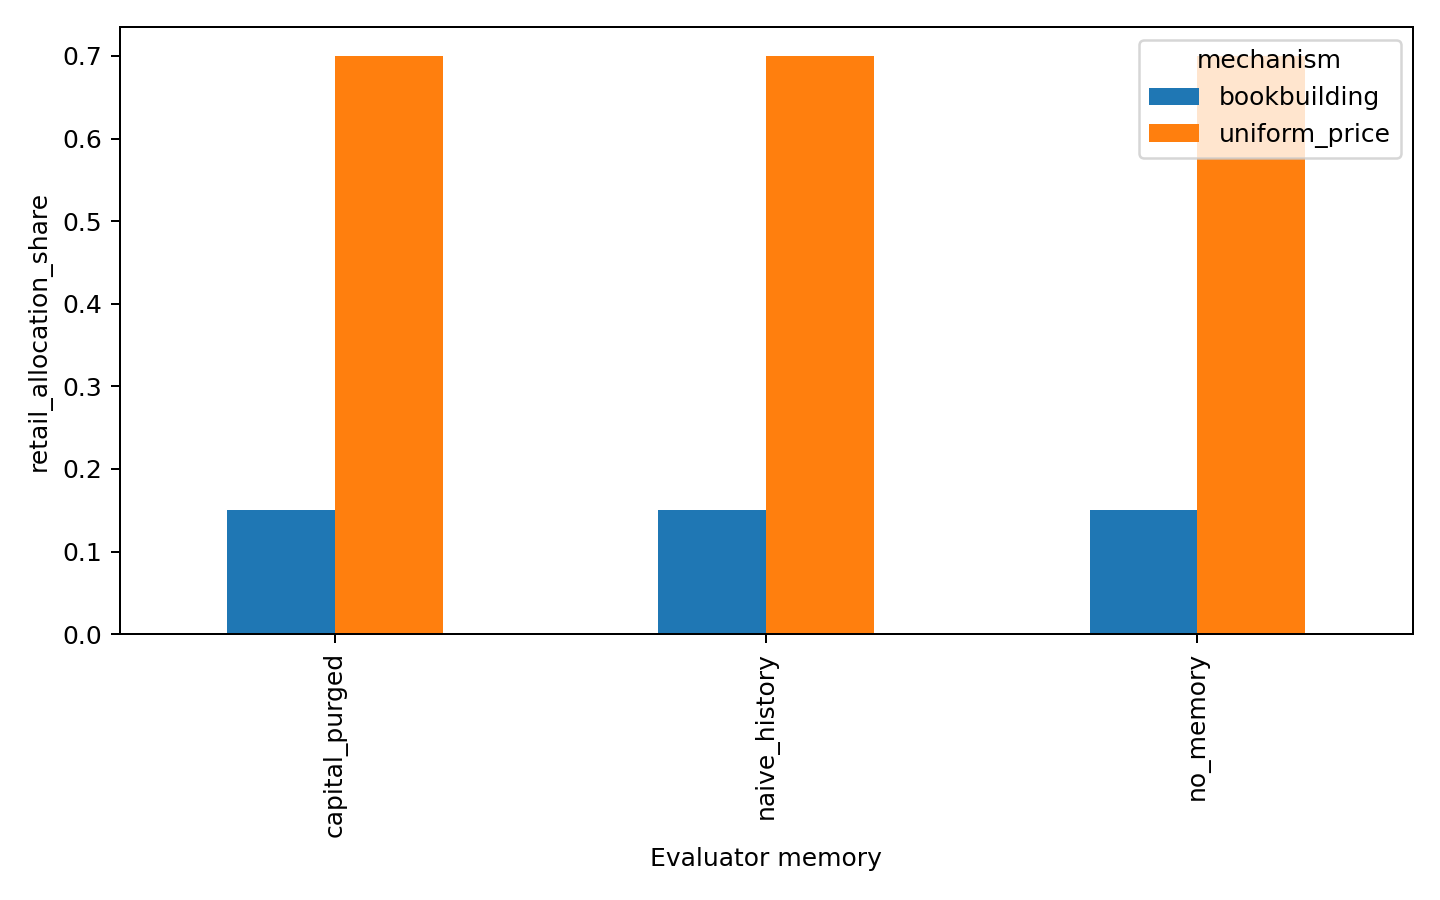

In [16]:
from IPython.display import Image, display

figure_files = [
    'manipulation.png',
    'price_rmse.png',
    'allocation_efficiency.png',
    'feedback_bias.png',
    'retail_access.png'
]

for filename in figure_files:
    path = results_dir / filename
    print('\n' + filename)
    display(Image(filename=str(path), width=700))

## 16. Verify burn-in and experiment dimensions

In [17]:
print('Seeds:', [42,43,44,45,46])
print('Evaluator treatments:', list(MODES))
print('Allocation mechanisms:', list(MECHANISMS))
print('Cohorts in full dataset:', sorted(main_results['cohort'].unique()))
print('Issuers in full dataset:', main_results['firm_id'].nunique())

analysis_results = main_results[main_results['cohort'] >= cfg.burn_in_cohorts].copy()
print('Observations after burn-in:', len(analysis_results))
print('Burn-in cohorts:', cfg.burn_in_cohorts)

assert main_results['cohort'].nunique() == cfg.n_cohorts
assert main_results['firm_id'].nunique() == cfg.n_issuers
assert sorted(main_results['cohort'].unique()) == list(range(cfg.n_cohorts))
assert cfg.burn_in_cohorts == 2
print('Experiment-dimension checks passed.')

Seeds: [42, 43, 44, 45, 46]
Evaluator treatments: ['no_memory', 'naive_history', 'capital_purged']
Allocation mechanisms: ['uniform_price', 'bookbuilding']
Cohorts in full dataset: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Issuers in full dataset: 200
Observations after burn-in: 4800
Burn-in cohorts: 2
Experiment-dimension checks passed.


## 17. Reproducibility record

The canonical script records the core random seeds and configuration. This notebook adds the exact SHA-256 hashes of the five files uploaded for this run and the installed package versions.

In [18]:
import json, platform, datetime
import numpy as np, pandas as pd, matplotlib

record_path = results_dir / 'fresh_run_record.json'
record = json.loads(record_path.read_text())

verification_record = {
    'run_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(),
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'matplotlib': matplotlib.__version__,
    'canonical_file_sha256': file_hashes,
    'script_record': record,
}

Path('results/colab_verification_record.json').write_text(
    json.dumps(verification_record, indent=2)
)
print(json.dumps(verification_record, indent=2))

{
  "run_utc": "2026-09-28T19:00:13.837728+00:00",
  "python": "3.13.5",
  "numpy": "2.3.5",
  "pandas": "2.2.3",
  "matplotlib": "3.10.8",
  "canonical_file_sha256": {
    "model.py": "06187927125a4b43acc2f6b582505c577f98e295b7bfb47b63ab91412d67915d",
    "evaluator.py": "e95ebda8b81818501a74c654cf50c8bd742235f17c3e5ffb0ec3dff641886fd7",
    "auction.py": "9a10bb9e2532788b22a8aad816ab01e203762bb80b6d6a230d6ed0e0e7333cb5",
    "simulation.py": "5513c81bc18dcbe549d50e6e8fb300ad4da859cc0ffe34ca0a9c6af07584312b",
    "run_experiment.py": "12cddfae0eb41612398d89d738ce7a4799512941d4520bebee785adbcef1f4bf"
  },
  "script_record": {
    "seeds": [
      42,
      43,
      44,
      45,
      46
    ],
    "n_issuers": 200,
    "cohorts": 10,
    "issuers_per_cohort": 20,
    "burn_in_cohorts": 2,
    "shares": 100.0,
    "gamma": 0.006,
    "sigma_theta": 1.0,
    "sigma_eta": 0.5,
    "mu0": 8.5,
    "beta": 0.6,
    "lambda": 1.0,
    "sigma_epsilon": 0.8,
    "institutional": 15,
    "ret

## 18. Final numerical table for the paper

**This table is the single numerical source for the final Overleaf revision.** Copy values from this output rather than retyping numbers from an earlier draft or poster.

In [19]:
final_table = summary[[
    'memory','mechanism','mean_manipulation','mean_manipulation_cost',
    'price_rmse','capital_rho_corr','feedback_bias',
    'footprint_cov_k_d_over_var_d','retail_allocation_share',
    'mean_first_stage_F','mean_capital'
]].sort_values(['memory','mechanism']).reset_index(drop=True)

display(final_table)
final_table.to_csv(results_dir / 'final_paper_summary.csv', index=False)
print('Saved: results/final_paper_summary.csv')

,memory,mechanism,mean_manipulation,mean_manipulation_cost,price_rmse,capital_rho_corr,feedback_bias,footprint_cov_k_d_over_var_d,retail_allocation_share,mean_first_stage_F,mean_capital
0,capital_purged,bookbuilding,1.002346,107.818606,14.320513,0.014451,2.526922,5.399278,0.15,0.899504,18.491474
1,capital_purged,uniform_price,1.276756,198.526846,26.478291,0.015275,4.893915,10.487949,0.70,0.136189,26.315612
2,naive_history,bookbuilding,0.920814,91.927863,12.302000,-0.006997,2.012377,4.438084,0.15,0.866363,16.642243
3,naive_history,uniform_price,1.366761,243.229848,30.327759,-0.011869,5.343903,11.777588,0.70,0.139973,28.322286
4,no_memory,bookbuilding,0.407777,14.304540,0.776329,0.036946,0.402932,0.824780,0.15,2.286989,7.767813
5,no_memory,uniform_price,0.407777,14.304540,0.550512,0.055276,0.460594,0.946223,0.70,0.310002,8.096784


Saved: results/final_paper_summary.csv


## 19. What the computation does and does not establish

- The numerical outputs are **simulation results**, not estimates from real financial-market data.
- The Hugging Face game is an exploratory behavioral artifact; classroom/self-selected play should not be interpreted as population-level evidence.
- The canonical simulation treats the AI evaluator as a rule rather than an autonomous learning agent.
- The current implementation reports the metrics produced by `run_experiment.py`; it does **not** independently invent underpricing or waste statistics.
- Any extension not actually run here should remain labeled **planned** in the paper and poster.

This boundary follows the PS2 requirement to distinguish actual output from planned evidence.

## 20. Three-lens interpretation

### Game theory
The firm strategically chooses disclosure manipulation $m$ while anticipating how the evaluator maps disclosure into valuation and how capital affects later performance. The computational benchmark is the canonical best-response/simulation environment.

### Social choice
The relevant stakeholders include issuers, institutional investors, retail investors, and future investors who rely on AI-generated prices. The simulation therefore reports multiple outcomes rather than collapsing them into one welfare score: disclosure, pricing error, allocation, feedback risk, and retail access.

### Mechanism design
The design question is whether evaluator memory and the capital-allocation rule jointly change incentives and downstream outcomes. The two allocation mechanisms are compared under the same three evaluator treatments.

## 21. Final artifact-parity checklist

Before submitting, verify all boxes:

- [ ] The five uploaded Python files are exactly the canonical GitHub files.
- [ ] Overleaf uses the same mathematical model and parameter values.
- [ ] Overleaf uses the same three evaluator treatments.
- [ ] Overleaf uses the same two allocation mechanisms.
- [ ] Overleaf reports numbers from `results/final_paper_summary.csv` from this run.
- [ ] Poster reports the same numerical results as Overleaf.
- [ ] Hugging Face presents the same strategic disclosure setting and labels classroom evidence as exploratory.
- [ ] Seeds are 42–46.
- [ ] Two-cohort burn-in is implemented consistently.
- [ ] `results/colab_verification_record.json` is preserved with the final computational artifacts.
- [ ] Any unrun extension is explicitly labeled planned.

# End of notebook

**Overleaf** → mathematical model and research argument  
**Hugging Face** → behavioral decision interface  
**Python** → canonical computational implementation  
**Colab** → runnable verification and fresh results  
**GitHub** → reproducible source and final commit/release  
**A0 Poster** → integrated communication of question, evidence, limitations, and implications